In [18]:
# Import libraries when needed

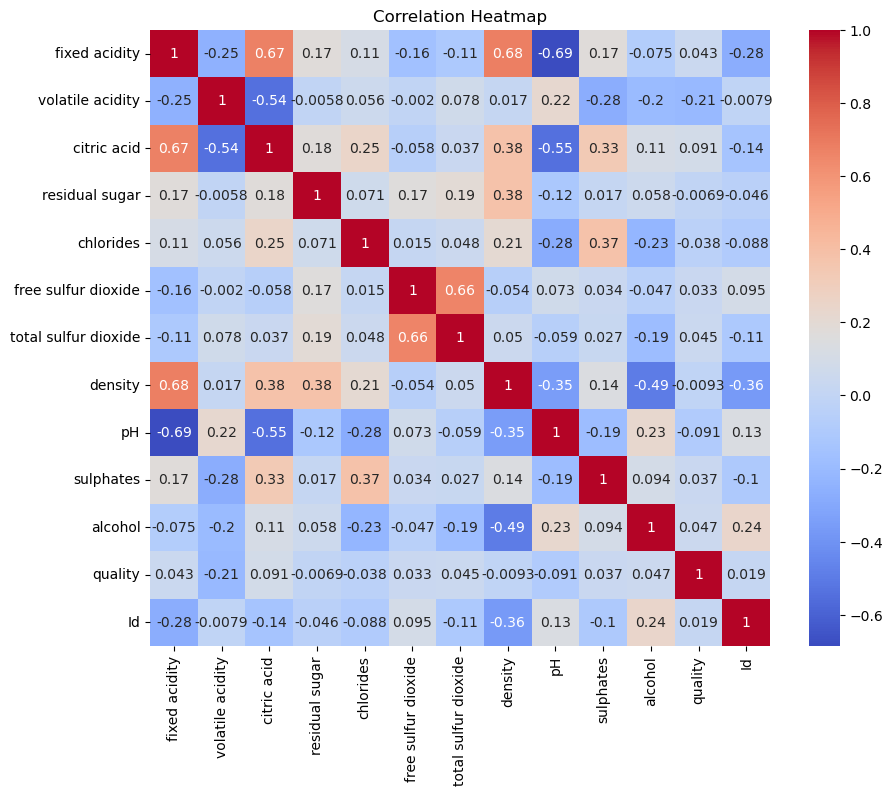

In [19]:
# Load Dataset
import pandas as pd
data = pd.read_csv("WineQT.csv")
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 5 else 0)
X = data.drop('quality', axis=1)
y = data['quality']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Plot Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [20]:
# Parameter Grid
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
results = {}
times = {}
model = RandomForestClassifier(random_state=42)

In [21]:
# Grid Search
start = time.time()
grid = GridSearchCV(model, param_grid, cv=5)
grid.fit(X_train, y_train)
end = time.time()

y_pred = grid.predict(X_test)

results['Grid'] = accuracy_score(y_test, y_pred)
times['Grid'] = end - start

In [17]:
# Random Search
start = time.time()
random = RandomizedSearchCV(model, param_grid, cv=5, n_iter=10, random_state=42)
random.fit(X_train, y_train)
end = time.time()

y_pred = random.predict(X_test)

results['Random'] = accuracy_score(y_test, y_pred)
times['Random'] = end - start

In [22]:
# Successive Halving
start = time.time()
halving = HalvingGridSearchCV(model, param_grid, cv=5)
halving.fit(X_train, y_train)
end = time.time()

y_pred = halving.predict(X_test)

results['Halving'] = accuracy_score(y_test, y_pred)
times['Halving'] = end - start

In [23]:
# Print Results
print('Random Forest Results')
print(results)
print('Time Taken')
print(times)

Random Forest Results
{'Grid': 0.9606986899563319, 'Halving': 0.9650655021834061}
Time Taken
{'Grid': 16.470192670822144, 'Halving': 18.22514533996582}


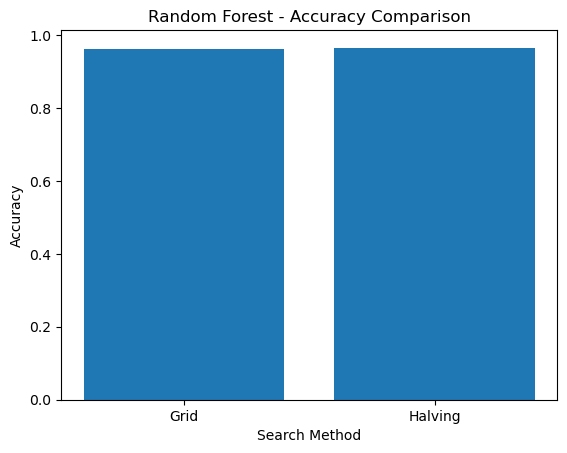

In [24]:
# Plot Accuracy Graph
import matplotlib.pyplot as plt
plt.figure()
plt.bar(results.keys(), results.values())
plt.title('Random Forest - Accuracy Comparison')
plt.xlabel('Search Method')
plt.ylabel('Accuracy')
plt.show()

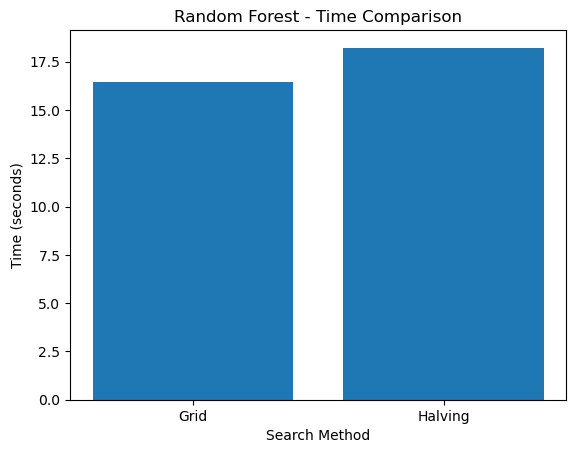

In [25]:
# Plot Time Graph
import matplotlib.pyplot as plt
plt.figure()
plt.bar(times.keys(), times.values())
plt.title('Random Forest - Time Comparison')
plt.xlabel('Search Method')
plt.ylabel('Time (seconds)')
plt.show()